In [1]:
!pip3 install matplotlib pandas &> /dev/null # Do not expose PII

In [2]:
import matplotlib.pyplot as plt
from legend import draw_legend

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.default"] = "sf"
plt.rcParams["font.size"] = 8
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["legend.fontsize"] = 6
plt.rcParams["legend.framealpha"] = 0.95
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["lines.linewidth"] = 1
plt.rcParams["lines.markersize"] = 2
plt.rcParams["axes.linewidth"] = 0.5
plt.rcParams["xtick.major.width"] = 0.5
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.major.width"] = 0.5
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["font.sans-serif"] = ["Times New Roman"]
plt.rcParams["hatch.linewidth"] = 0.5

LINEWIDTH = 252 / 72 # \linewidth from pts to inches
HEIGHT = LINEWIDTH / 2.5

In [75]:
fig, ax = plt.subplots(figsize=(LINEWIDTH, HEIGHT), layout="constrained")
ax.plot([0, 0], [1, 1], label="a1")
ax.plot([0, 0], [1, 1], label="a2")
ax.plot([0, 0], [1, 1], label="a3")
legend = draw_legend(ax, ncol=3)
renderer = fig.canvas.get_renderer()
bbox = legend.get_window_extent(renderer=renderer)
ax_bbox = ax.get_window_extent(renderer=renderer)
padding = (bbox.y0 - ax_bbox.y1)
LEGEND_HEIGHT = (bbox.height + padding) / fig.dpi - 0.09
plt.close(fig)

In [3]:
import json
import matplotlib.ticker as plticker
import pandas as pd
import ipaddress

def get_graph_data(file, all_labels={}, filter_stages=[]):
    with open(file) as graph_file:
        graphs = []
        for line in graph_file:
            line = line.rstrip()
            parts = line.split(",", 1)
            key = parts[0]
            graph = json.loads(parts[1])
            labels = {}
            internet_nodes = {}
            internet_nodes_direction = []
            ids_alerts = 0

            for relation in graph["relations"]:
                if relation["stage"] not in filter_stages:
                    ids_alerts += relation["count"]
                    
                    if "labels" in relation:
                        for label in relation["labels"]:
                            if label in labels:
                                labels[label] += 1
                            else:
                                labels[label] = 1
                    elif "label" in relation:
                        label = relation["label"]
                        if label in labels:
                            labels[label] += 1
                        else:
                            labels[label] = 1
                    
                    source = relation["from"]
                    if not ipaddress.ip_address(source).is_private:
                        internet_nodes[source] = True
                        if "source" not in internet_nodes_direction:
                            internet_nodes_direction.append("source")

                    destination = relation["to"]
                    if not ipaddress.ip_address(destination).is_private:
                        internet_nodes[destination] = True
                        if "destination" not in internet_nodes_direction:
                            internet_nodes_direction.append("destination")

            graph_info = {
                "id": key,
                "relevance": graph["computed_relevance"],
                "label_count": sum([labels[key] for key in labels.keys()]),
                "size": len(graph["relations"]),
                "internet_nodes": len(internet_nodes.keys()),
                "internet_nodes_direction": internet_nodes_direction,
                "ids_alerts": ids_alerts,
            }

            for label in labels.keys():
                graph_info[f"label_{label}"] = labels[label]

            graphs.append(graph_info)

        graphs = sorted(graphs, key=lambda graph: graph["relevance"], reverse=True)
        ids = []
        relevances = []
        sizes = []
        internet_nodes = []
        internet_nodes_direction = []
        ids_alerts = []
        label_counts = []

        for graph in graphs:
            ids.append(graph["id"])
            relevances.append(graph["relevance"])
            sizes.append(graph["size"])
            internet_nodes.append(graph["internet_nodes"])
            internet_nodes_direction.append(len(graph["internet_nodes_direction"]))
            ids_alerts.append(graph["ids_alerts"])
            label_counts.append(graph["label_count"])
            
            for label in all_labels.keys():
                if label in graph:
                    all_labels[label].append(graph[label])
                else:
                    all_labels[label].append(0)

        data = {
            "id": ids,
            "relevance": relevances,
            "label_counts": label_counts,
            "size": sizes,
            "internet_nodes": internet_nodes,
            "internet_nodes_direction": internet_nodes_direction,
            "ids_alerts": ids_alerts,
        }

        for label_key in all_labels.keys():
            data[label_key] = all_labels[label_key]

        df = pd.DataFrame(data=data)
    
        return df

def plot_graph_size_distribution(df, number=5):
    fig, ax = plt.subplots(figsize=(LINEWIDTH, HEIGHT), layout="constrained")

    x = [x+1 for x in df.index.values][:number]
    handles = []

    plot, = ax.plot(x, df["relevance"][:number].values, linestyle="-", marker="s", label="Relevance", color="orange")
    handles.append(plot)
    ax2 = ax.twinx()
    plot, = ax2.plot(x, df["size"][:number].values, linestyle="-", marker="x", label="Size")
    handles.append(plot)

    if len(df["size"]) > 0:
        print(df["size"][0])

    ax.legend(handles=handles)

    ax.set_ylim([0, 1])

    loc = plticker.MultipleLocator(base=1.0)
    ax.xaxis.set_major_locator(loc)

In [4]:
# prefix labels with label_

df_ids2018_apt = get_graph_data("data/results/ids2018-apt/custom-weights/graphs.json", {
    "label_benign": [],
    "label_apt_attack": [],
})

df_ids2018_apt_no_reconnaissance = get_graph_data("data/results/ids2018-apt/custom-weights/graphs.json", {
    "label_benign": [],
    "label_apt_attack": [],
}, filter_stages=[0]) # filter reconnaissance stage

df_ids2017 = get_graph_data("data/results/ids2017/custom-weights/graphs.json", {
    "label_benign": [],
    "label_other_attack_tuesday_ftp": [],
    "label_other_attack_tuesday_ssh": [],
    "label_other_attack_wednesday_dos_slowloris": [],
    "label_other_attack_wednesday_dos_slowhttptest": [],
    "label_other_attack_wednesday_dos_hulk": [],
    "label_other_attack_wednesday_dos_goldeneye": [],
    "label_other_attack_wednesday_heartbleed": [],
    "label_other_attack_thursday_web_brute_force": [],
    "label_other_attack_thursday_web_xss": [],
    "label_other_attack_thursday_web_sql_injection": [],
    "label_other_attack_thursday_first_infiltration": [],
    "label_other_attack_thursday_cool_disk": [],
    "label_other_attack_friday_botnet": [],
    "label_other_attack_friday_port_scan": [],
    "label_other_attack_friday_ddos_loit": [],
    "label_apt_attack": [],
})

df_ids2018 = get_graph_data("data/results/ids2018/custom-weights/graphs.json", {
    "label_benign": [],
    "label_botnet": [],
    "label_ddos-1-loic-http": [],
    "label_ddos-2-loic-udp-1": [],
    "label_ddos-2-loic-udp-2": [],
    "label_ddos-3-hoic": [],
    "label_dos-1-hulk": [],
    "label_dos-2-goldeneye": [],
    "label_dos-3-slowloris": [],
    "label_ftp-bruteforce-1": [],
    "label_ftp-bruteforce-2": [],
    "label_ftp-bruteforce-3": [],
    "label_multi-stage-dropbox-download-1": [],
    "label_multi-stage-dropbox-download-2": [],
    "label_multi-stage-infiltration-1": [],
    "label_multi-stage-infiltration-2": [],
    "label_multi-stage-nmap-1": [],
    "label_multi-stage-nmap-2": [],
    "label_sql-injection-1": [],
    "label_sql-injection-2": [],
    "label_ssh-bruteforce-1-patator": [],
    "label_web-bruteforce-1": [],
    "label_web-bruteforce-2": [],
    "label_xss-1": [],
    "label_xss-2": [],
})

### With equal weights

df_ids2018_apt_equal_weights = get_graph_data("data/results/ids2018-apt/equal-weights/graphs.json", {
    "label_benign": [],
    "label_apt_attack": [],
})

df_ids2017_equal_weights = get_graph_data("data/results/ids2017/equal-weights/graphs.json", {
    "label_benign": [],
    "label_other_attack_tuesday_ftp": [],
    "label_other_attack_tuesday_ssh": [],
    "label_other_attack_wednesday_dos_slowloris": [],
    "label_other_attack_wednesday_dos_slowhttptest": [],
    "label_other_attack_wednesday_dos_hulk": [],
    "label_other_attack_wednesday_dos_goldeneye": [],
    "label_other_attack_wednesday_heartbleed": [],
    "label_other_attack_thursday_web_brute_force": [],
    "label_other_attack_thursday_web_xss": [],
    "label_other_attack_thursday_web_sql_injection": [],
    "label_other_attack_thursday_first_infiltration": [],
    "label_other_attack_thursday_cool_disk": [],
    "label_other_attack_friday_botnet": [],
    "label_other_attack_friday_port_scan": [],
    "label_other_attack_friday_ddos_loit": [],
    "label_apt_attack": [],
})


df_ids2018_equal_weights = get_graph_data("data/results/ids2018/equal-weights/graphs.json", {
    "label_benign": [],
    "label_botnet": [],
    "label_ddos-1-loic-http": [],
    "label_ddos-2-loic-udp-1": [],
    "label_ddos-2-loic-udp-2": [],
    "label_ddos-3-hoic": [],
    "label_dos-1-hulk": [],
    "label_dos-2-goldeneye": [],
    "label_dos-3-slowloris": [],
    "label_ftp-bruteforce-1": [],
    "label_ftp-bruteforce-2": [],
    "label_ftp-bruteforce-3": [],
    "label_multi-stage-dropbox-download-1": [],
    "label_multi-stage-dropbox-download-2": [],
    "label_multi-stage-infiltration-1": [],
    "label_multi-stage-infiltration-2": [],
    "label_multi-stage-nmap-1": [],
    "label_multi-stage-nmap-2": [],
    "label_sql-injection-1": [],
    "label_sql-injection-2": [],
    "label_ssh-bruteforce-1-patator": [],
    "label_web-bruteforce-1": [],
    "label_web-bruteforce-2": [],
    "label_xss-1": [],
    "label_xss-2": [],
})

In [ ]:
df_ids2018

,id,relevance,label_counts,size,internet_nodes,internet_nodes_direction,ids_alerts,label_benign,label_botnet,label_ddos-1-loic-http,...,label_multi-stage-infiltration-2,label_multi-stage-nmap-1,label_multi-stage-nmap-2,label_sql-injection-1,label_sql-injection-2,label_ssh-bruteforce-1-patator,label_web-bruteforce-1,label_web-bruteforce-2,label_xss-1,label_xss-2
0,6474,0.500000,42,42,40,2,92,42,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5486,0.458333,109,109,89,2,125,104,0,0,...,0,4,0,0,0,0,0,0,0,0
2,12071,0.441667,47,47,38,2,67,47,0,0,...,0,0,0,0,0,0,0,0,0,0
3,10856,0.441667,62,62,50,2,136,62,0,0,...,0,0,0,0,0,0,0,0,0,0
4,16423,0.441667,36,36,32,2,107,36,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254005,161894,0.016667,1,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
254006,262416,0.016667,1,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
254007,337970,0.016667,1,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
254008,15087,0.016667,1,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print("CIC-IDS2017", df_ids2017["ids_alerts"].sum())
print("CSE-CIC-IDS2018", df_ids2018["ids_alerts"].sum())
print("CSE-CIC-IDS2018-APT", df_ids2018_apt["ids_alerts"].sum())

CIC-IDS2017 23855
CSE-CIC-IDS2018 396141
CSE-CIC-IDS2018-APT 452301


42


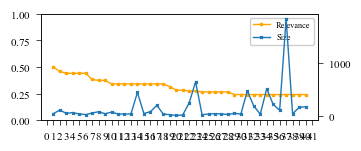

In [ ]:
plot_graph_size_distribution(df_ids2018, number=40)

885


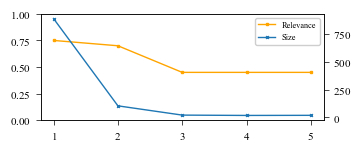

In [ ]:
plot_graph_size_distribution(df_ids2018_apt)

6


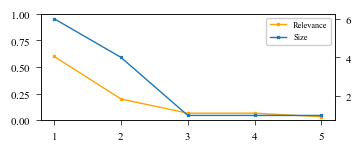

In [ ]:
plot_graph_size_distribution(df_ids2017)

In [6]:
def calc_threshold(df, beta=0.9):
    scores = df["relevance"].unique()
    index = int(len(scores) * (1-beta))
    if index < len(scores):
        top_score = scores[index]
    else:
        top_score = 0
    graph_count = len(df[df['relevance'] >= top_score])
    return graph_count, top_score

print(calc_threshold(df_ids2018_apt, 0.9))

(1, np.float64(0.75))


CIC-IDS2017
Graph count: 1 / 1 (beta = 1.0, #alerts = 6)
Graph count: 1 / 1 (beta = 0.95, #alerts = 6)
Graph count: 1 / 1 (beta = 0.9, #alerts = 6)
Graph count: 1 / 1 (beta = 0.85, #alerts = 6)
Graph count: 1 / 1 (beta = 0.8, #alerts = 6)
Graph count: 1 / 2 (beta = 0.75, #alerts = 10)
Graph count: 1 / 2 (beta = 0.7, #alerts = 10)
Graph count: 1 / 2 (beta = 0.65, #alerts = 10)
Graph count: 1 / 2 (beta = 0.6, #alerts = 10)
Graph count: 1 / 2 (beta = 0.55, #alerts = 10)
Graph count: 1 / 4 (beta = 0.5, #alerts = 12)
Graph count: 1 / 4 (beta = 0.45, #alerts = 12)
Graph count: 1 / 4 (beta = 0.4, #alerts = 12)
Graph count: 1 / 4 (beta = 0.35, #alerts = 12)
Graph count: 1 / 4 (beta = 0.3, #alerts = 12)
Graph count: 1 / 6 (beta = 0.25, #alerts = 14)
Graph count: 1 / 6 (beta = 0.2, #alerts = 14)
Graph count: 1 / 6 (beta = 0.15, #alerts = 14)
Graph count: 1 / 6 (beta = 0.1, #alerts = 14)
Graph count: 1 / 6 (beta = 0.05, #alerts = 14)
Graph count: 1 / 6 (beta = 0.0, #alerts = 14)
CSE-CIC-IDS2018
G

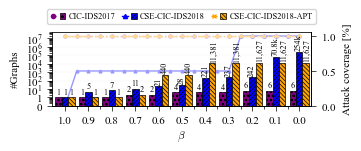

In [210]:
import numpy as np
import matplotlib
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, BoxStyle
from matplotlib.legend_handler import HandlerTuple
import matplotlib.ticker as ticker
import math

fig, ax = plt.subplots(figsize=(LINEWIDTH, HEIGHT), layout="constrained")

betas = [round(1-(x*5)/100, 2) for x in range(0, 21)]

graph_sizes = {
        "CIC-IDS2017": {
        "df": df_ids2017,
        "color": "purple",
        "hatch": "oooo",
        "labels": [
            "label_apt_attack"
        ],
        "linestyle": ":",
        "marker": "o",
    },
    "CSE-CIC-IDS2018": {
        "df": df_ids2018,
        "color": "blue",
        "hatch": "////////",
        "labels": [
            "label_multi-stage-dropbox-download-1",
            "label_multi-stage-dropbox-download-2",
            "label_multi-stage-infiltration-1",
            "label_multi-stage-infiltration-2",
            "label_multi-stage-nmap-1",
            "label_multi-stage-nmap-2",
        ],
        "linestyle": "-",
        "marker": "^",
    },
    "CSE-CIC-IDS2018-APT": {
        "df": df_ids2018_apt,
        "color": "orange",
        "hatch": "\\\\\\\\\\\\\\\\",
        "labels": [
            "label_apt_attack"
        ],
        "linestyle": "-.",
        "marker": "x",
    }
}

x = np.arange(len(betas))

width = 0.55  # the width of the bars
multiplier = 0

def calc_correct_graph_count(df, columns):
    filter_statements = []
    for column in columns:
        filter_statements.append(f"`{column}` > 0")
    return len(df.query(" or ".join(filter_statements)))

ax2 = ax.twinx()
handles = []
handle_labels = []
max_count = 0

for key, measurement in graph_sizes.items():
    counts = []
    coverages = []
    print(key)
    mdf = measurement["df"]

    total_correct_graph_count = calc_correct_graph_count(mdf, measurement["labels"])

    for beta in betas:
        graph_count, t = calc_threshold(mdf, beta=beta)

        alert_count = mdf[mdf["relevance"] >= t]["size"].sum()
        counts.append(graph_count)

        correct_graph_count = calc_correct_graph_count(mdf[mdf["relevance"] >= t], measurement["labels"])
        coverages.append(correct_graph_count/total_correct_graph_count)

        print(f"Graph count: {correct_graph_count} / {graph_count} (beta = {beta}, #alerts = {alert_count})")

    offset = width * multiplier
    line, = ax2.plot(x + width * len(graph_sizes) / 2 - width / 2, coverages, color=measurement["color"], linestyle=measurement["linestyle"], zorder=1, marker=measurement["marker"])

    new_counts = []
    new_x = []
    new_betas = []
    for i in range(len(counts)):
        y = counts[i]
        x_num = x[i]
        if i % 2 == 0:
            new_counts.append(y)
            new_x.append(x_num)

    counts = np.array(new_counts)
    new_x = np.array(new_x)

    if counts[-1] > max_count:
        max_count = counts[-1]

    bars = ax.bar(new_x + offset, counts, width, label=key, color=measurement["color"], hatch=measurement["hatch"], edgecolor="black", zorder=20, linewidth=0.5)

    i = 0
    for bar in bars:
        if counts[i] > 50_000:
            label = round(counts[i]/1_000, 1)
            if round(label) == label:
                label = round(label)
            label = f"{label}k"
        else:
            label = f"{counts[i]:,}"

        rotation = 0
        left_padding = 0
        backgroundcolor="none"
        if counts[i] > 20:
            rotation = 90
            left_padding = 1
            if "," not in label:
                left_padding = 0
            backgroundcolor = (1.0, 1.0, 1.0, 0.4)

        ax.annotate(
            label,
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(left_padding, 1),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=6,
            rotation=rotation,
        )
        i += 1

    handles.append((
        line, # Line
        bars # Bar
    ))
    handle_labels.append(key)
    multiplier += 1

new_betas = []

for i in range(len(betas)):
    beta = betas[i]
    if i % 2 == 0:
        new_betas.append(beta)

y_limit = (round(math.log10(max_count))+1)**10

ax.set_xticks(new_x + width, new_betas)
ax.set_xticks(x + width, betas, minor=True)
ax.set_yscale("log")
ax.yaxis.set_major_locator(ticker.LogLocator(numticks=10))
ax.yaxis.set_major_formatter(lambda x, pos: r"10$^{\mathdefault{" + str(math.floor(math.log10(x))) + "}}$" if x > 1 else int(x))
ax.yaxis.set_minor_locator(ticker.LogLocator(numticks=10, base=10, subs=np.arange(1, 10)))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
ax.set_ylabel("#Graphs")
ax.set_xlabel(r"$\mathrm{\beta}$", usetex=True)
ax.set_xlim(-width, 21+width)
ax.patch.set_facecolor('white')
ax.patch.set_alpha(0.2)
ax.set_ylim(0.1, y_limit)

# Define span region
x0, x1 = ax.get_xlim()

ax.axvspan(
    xmin=x0,
    xmax=x1,
    facecolor="white",
    alpha=0.5,
    zorder=1
)

ax2.set_yscale("linear")
ax2.set_ylim(0, 1.128)
ax2.set_ylabel("Attack coverage [%]")
ax2.patch.set_visible(False)
ax2.set_zorder(1)
ax2.set_ylim(0, 1.06)


ax.set_zorder(ax2.get_zorder()+1)

# Grid
ax3 = ax.twinx()
ax3.plot([0, 1], [1, max_count], alpha=0)
ax3.set_zorder(0)
ax3.set_yscale("log")
ax3.yaxis.set_major_locator(ticker.LogLocator(numticks=10))
ax3.grid(axis="y", which="both", linestyle="-", linewidth=0.1, zorder=0)
ax3.patch.set_visible(False)
ax3.set_axisbelow(True)
ax3.set_ylim(0.1, y_limit)
ax3.tick_params(axis="y", labelright=False, length=0)

draw_legend(ax, handles=handles, labels=handle_labels, handler_map={tuple: HandlerTuple(ndivide=None)}, ncol=3)

fig.savefig("figures/thresholds.pdf", transparent=True)

In [ ]:
def calc_recall(df, attacks_columns):
    attacks = []
    i = 0
    for attack_columns in attacks_columns:
        i += 1
        filter_statements = []
        for column in attack_columns:
            filter_statements.append(f"`{column}` > 0")
        attack = df.query(" or ".join(filter_statements)).copy()
        tp = attack.loc[:,attack_columns].sum().sum()
        attack.loc[:,"attack"] = i
        attack.loc[:,"total"] = attack.loc[:,"size"]
        attack.loc[:,"tp"] = tp
        attack.loc[:,"fp"] = attack.loc[:, "label_benign"]
        attack.loc[:,"recall"] = attack.loc[:, attack_columns].sum(axis = 1) / tp
        attacks.append(attack)

    return pd.concat(attacks)

In [ ]:
calc_recall(df_ids2018, attacks_columns=[[
    "label_multi-stage-dropbox-download-1",
    "label_multi-stage-infiltration-1",
    "label_multi-stage-nmap-1",
],[
    "label_multi-stage-dropbox-download-2",
    "label_multi-stage-infiltration-2",
    "label_multi-stage-nmap-2",
]])

,id,relevance,label_counts,size,internet_nodes,internet_nodes_direction,ids_alerts,label_benign,label_botnet,label_ddos-1-loic-http,...,label_ssh-bruteforce-1-patator,label_web-bruteforce-1,label_web-bruteforce-2,label_xss-1,label_xss-2,attack,total,tp,fp,recall
1,5486,0.458333,109,109,89,2,125,104,0,0,...,0,0,0,0,0,1,109,5,104,1.0
237,7505,0.108333,85,85,65,1,587,77,0,0,...,0,0,0,0,0,2,85,8,77,1.0


In [ ]:
calc_recall(df_ids2018_apt, attacks_columns=[[
    "label_apt_attack",
]])

,id,relevance,label_counts,size,internet_nodes,internet_nodes_direction,ids_alerts,label_benign,label_apt_attack,attack,total,tp,fp,recall
0,1,0.75,885,885,841,2,1160,876,9,1,885,9,876,1.0


In [ ]:
calc_recall(df_ids2018_apt_no_reconnaissance, attacks_columns=[[
    "label_apt_attack",
]])

,id,relevance,label_counts,size,internet_nodes,internet_nodes_direction,ids_alerts,label_benign,label_apt_attack,attack,total,tp,fp,recall
0,1,0.75,35,885,30,1,44,29,6,1,885,6,29,1.0


In [ ]:
calc_recall(df_ids2017, attacks_columns=[[
    "label_apt_attack",
]])
# The 4 labels (9 total - 5 TP) are coming from activity shortly before the attack

,id,relevance,label_counts,size,internet_nodes,internet_nodes_direction,ids_alerts,label_benign,label_other_attack_tuesday_ftp,label_other_attack_tuesday_ssh,...,label_other_attack_thursday_cool_disk,label_other_attack_friday_botnet,label_other_attack_friday_port_scan,label_other_attack_friday_ddos_loit,label_apt_attack,attack,total,tp,fp,recall
0,2,0.6,9,6,1,1,23845,0,0,0,...,0,0,0,0,5,1,6,5,0,1.0


In [ ]:
def pruned_graphs(df):
    # same pruning method as Wilkens et al.: Every graph with only one internal node and only a single direction
    new_df = df[(df["size"] != 1) | (df["internet_nodes_direction"] != 1)]
    return new_df

pruned_ids2018 = pruned_graphs(df_ids2018)
pruned_ids2018_apt = pruned_graphs(df_ids2018_apt)
pruned_ids2017 = pruned_graphs(df_ids2017)


print("Number of meta-alerts")
print(pruned_ids2018["size"].sum())
print(pruned_ids2018_apt["size"].sum())
print(pruned_ids2017["size"].sum())

print()

print("Number of graphs")
print(len(pruned_graphs(df_ids2018)))
print(len(pruned_graphs(df_ids2018_apt)))
print(len(pruned_graphs(df_ids2017)))

Number of meta-alerts
61493
334274
10

Number of graphs
237
686
2


In [ ]:
def number_of_alerts(df, k):
    return df[:k].sum()

print(number_of_alerts(df_ids2018_apt, 10000000))
print(number_of_alerts(df_ids2018, 10000000))
print(number_of_alerts(df_ids2017, 10000000))

id                          1401374603334664753033604770915111395381493543...
relevance                                                             1292.65
label_counts                                                           345215
size                                                                   345215
internet_nodes                                                         339648
internet_nodes_direction                                                11821
ids_alerts                                                             452301
label_benign                                                           345206
label_apt_attack                                                            9
dtype: object
id                                      6474548612071108561642366784771116214218464851...
relevance                                                                     8170.025337
label_counts                                                                       315266
size          

id                                                    2
relevance                                           0.6
label_counts                                          9
size                                                  6
internet_nodes                                        1
internet_nodes_direction                              1
ids_alerts                                        23845
label_benign                                          0
label_other_attack_tuesday_ftp                        0
label_other_attack_tuesday_ssh                        0
label_other_attack_wednesday_dos_slowloris            0
label_other_attack_wednesday_dos_slowhttptest         0
label_other_attack_wednesday_dos_hulk                 0
label_other_attack_wednesday_dos_goldeneye            0
label_other_attack_wednesday_heartbleed               0
label_other_attack_thursday_web_brute_force           0
label_other_attack_thursday_web_xss                   0
label_other_attack_thursday_web_sql_injection   

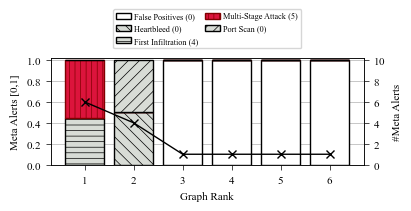

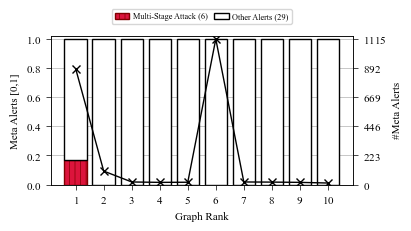

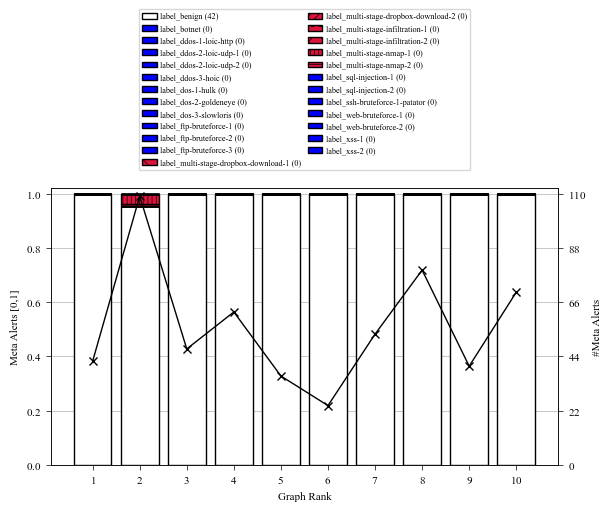

In [5]:
import matplotlib.ticker as plticker
import numpy as np
import math


def false_positive_graph_distrbution(df, label_map={}, width=4, height=2.5, legend_columns=2):
    columns = label_map.keys()
    sums = df.sum()
    print(sums)

    x_relevance = [x + 1 for x in df.index]
    y_relevance = df["size"].values

    df = df[columns]
    df.insert(0, "sum", df[columns].sum(axis=1), True)
    df = (df[columns].T / df["sum"]).T

    markers = [".", "^", "<", ">"]

    bottom = np.zeros(len(df.index))

    handles = []

    fig, ax = plt.subplots(
        figsize=(width, height), layout="constrained"
    )

    for column in columns:
        edgecolor = "black"
        if "edgecolor" in label_map[column]:
            edgecolor = label_map[column]["edgecolor"]

        x = x_relevance
        y = df[column].values
        count = sums[column]
        if len(y) > 0:
            bar = ax.bar(
                x,
                y,
                width=0.8,
                linewidth=1,
                edgecolor=edgecolor,
                label=f"{label_map[column]['name']} ({count})",
                hatch=label_map[column]["hatch"],
                bottom=bottom,
                color=label_map[column]["color"],
            )
        bottom += y
        handles.append(bar)

    ax.set_ylim([-0, 1.02])
    ax.margins(0.01)
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="-", linewidth="0.5")

    ax2 = ax.twinx()

    (relevance_line,) = ax2.plot(
        x_relevance,
        y_relevance,
        marker="x",
        markersize=6,
        color="black",
        label="#Meta Alerts",
    )
    handles.append(relevance_line)

    if len(df.index) > 20:
        loc = plticker.MultipleLocator(base=10.0)
        ax.xaxis.set_major_locator(loc)
    else:
        loc = plticker.MultipleLocator(base=1.0)
        ax.xaxis.set_major_locator(loc)

    ax.yaxis.set_major_locator(plticker.MultipleLocator(base=0.2))
    y_limit_max = (5 - max(y_relevance) % 5) + max(y_relevance)
    ax2.yaxis.set_major_locator(plticker.MultipleLocator(base=y_limit_max / 5))
    ax2.set_ylim(0, y_limit_max * 1.02)
    draw_legend(ax, ncol=legend_columns)
    ax.set_xlabel("Graph Rank")
    ax.set_ylabel("Meta Alerts [0,1]")
    ax2.set_ylabel("#Meta Alerts")

    return fig


false_positive_graph_distrbution(
    df_ids2017,
    label_map={
        "label_benign": {
            "name": "False Positives",
            "color": "white",
            "hatch": "",
        },
        "label_other_attack_wednesday_heartbleed": {
            "name": "Heartbleed",
            "color": "xkcd:light grey",
            "hatch": "\\\\\\",
        },
        "label_other_attack_thursday_first_infiltration": {
            "name": "First Infiltration",
            "color": "xkcd:light grey",
            "hatch": "---",
        },
        "label_apt_attack": {
            "name": "Multi-Stage Attack",
            "color": "crimson",
            "edgecolor": "maroon",
            "hatch": "|||",
        },
        "label_other_attack_friday_port_scan": {
            "name": "Port Scan",
            "color": "xkcd:light grey",
            "hatch": "///",
        },
    },
    height=2
).savefig("figures/alert_distribution_cic_2017.pdf")


false_positive_graph_distrbution(
    df_ids2018_apt_no_reconnaissance[:10],
    label_map={
        "label_apt_attack": {
            "name": "Multi-Stage Attack",
            "color": "crimson",
            "edgecolor": "maroon",
            "hatch": "|||",
        },
        "label_benign": {"name": "Other Alerts", "color": "white", "hatch": ""},
    },
    height=2.2
).savefig("figures/alert_distribution_cse_2018-apt.pdf")

false_positive_graph_distrbution(
    df_ids2018[:10],
    label_map={
        "label_benign": {"name": "label_benign", "color": "white", "hatch": ""},
        "label_botnet": {"name": "label_botnet", "color": "blue", "hatch": ""},
        "label_ddos-1-loic-http": {
            "name": "label_ddos-1-loic-http",
            "color": "blue",
            "hatch": "",
        },
        "label_ddos-2-loic-udp-1": {
            "name": "label_ddos-2-loic-udp-1",
            "color": "blue",
            "hatch": "",
        },
        "label_ddos-2-loic-udp-2": {
            "name": "label_ddos-2-loic-udp-2",
            "color": "blue",
            "hatch": "",
        },
        "label_ddos-3-hoic": {"name": "label_ddos-3-hoic", "color": "blue", "hatch": ""},
        "label_dos-1-hulk": {"name": "label_dos-1-hulk", "color": "blue", "hatch": ""},
        "label_dos-2-goldeneye": {
            "name": "label_dos-2-goldeneye",
            "color": "blue",
            "hatch": "",
        },
        "label_dos-3-slowloris": {
            "name": "label_dos-3-slowloris",
            "color": "blue",
            "hatch": "",
        },
        "label_ftp-bruteforce-1": {
            "name": "label_ftp-bruteforce-1",
            "color": "blue",
            "hatch": "",
        },
        "label_ftp-bruteforce-2": {
            "name": "label_ftp-bruteforce-2",
            "color": "blue",
            "hatch": "",
        },
        "label_ftp-bruteforce-3": {
            "name": "label_ftp-bruteforce-3",
            "color": "blue",
            "hatch": "",
        },
        "label_multi-stage-dropbox-download-1": {
            "name": "label_multi-stage-dropbox-download-1",
            "color": "crimson",
            "hatch": "\\\\",
        },
        "label_multi-stage-dropbox-download-2": {
            "name": "label_multi-stage-dropbox-download-2",
            "color": "crimson",
            "hatch": "////",
        },
        "label_multi-stage-infiltration-1": {
            "name": "label_multi-stage-infiltration-1",
            "color": "crimson",
            "hatch": "oo",
        },
        "label_multi-stage-infiltration-2": {
            "name": "label_multi-stage-infiltration-2",
            "color": "crimson",
            "hatch": "xx",
        },
        "label_multi-stage-nmap-1": {
            "name": "label_multi-stage-nmap-1",
            "color": "crimson",
            "hatch": "||||",
        },
        "label_multi-stage-nmap-2": {
            "name": "label_multi-stage-nmap-2",
            "color": "crimson",
            "hatch": "----",
        },
        "label_sql-injection-1": {
            "name": "label_sql-injection-1",
            "color": "blue",
            "hatch": "",
        },
        "label_sql-injection-2": {
            "name": "label_sql-injection-2",
            "color": "blue",
            "hatch": "",
        },
        "label_ssh-bruteforce-1-patator": {
            "name": "label_ssh-bruteforce-1-patator",
            "color": "blue",
            "hatch": "",
        },
        "label_web-bruteforce-1": {
            "name": "label_web-bruteforce-1",
            "color": "blue",
            "hatch": "",
        },
        "label_web-bruteforce-2": {
            "name": "label_web-bruteforce-2",
            "color": "blue",
            "hatch": "",
        },
        "label_xss-1": {"name": "label_xss-1", "color": "blue", "hatch": ""},
        "label_xss-2": {"name": "label_xss-2", "color": "blue", "hatch": ""},
    },
    width=6,
    height=5,
).savefig("figures/alert_distribution_cse_2018.pdf")

#meta alerts =  345215
#meta alerts =  14
#meta alerts =  315266


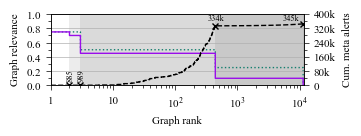

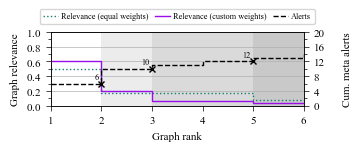

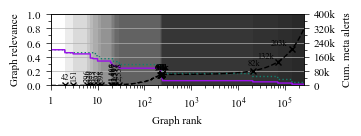

In [85]:
import matplotlib.ticker as mtick
import math

def plot_relevance_and_number_of_alerts(df, left_padding=0, bottom_padding=3, horizontal_alignment="center", no_legend=False):
    legend_space = 0
    if no_legend:
        legend_space = LEGEND_HEIGHT

    fig, ax = plt.subplots(figsize=(LINEWIDTH, HEIGHT-legend_space), layout="constrained")
    x = [x+1 for x in df.index]
    df["size_cumsum"] = df["size"].cumsum()

    handles = []

    ax2 = ax.twinx()
    y_lim_max = (df["size_cumsum"].max() % 5) + df["size_cumsum"].max()
    
    if len(df) > 100:
        ax2.set_xscale("log")
    
    ax2.set_xlim([1, len(df)])

    relevance_change_alert_counts = []
    relevance_change_graph_counts = []

    for i in range(len(x)):
        if i > 0:
            if df["relevance"].values[i] != df["relevance"].values[i-1]:
                y_value = df["size_cumsum"].values[i-1]
                ax.axvspan(i+1, len(x), color="black", linestyle="", alpha=0.075, zorder=1)

                relevance_change_alert_counts.append(y_value)
                relevance_change_graph_counts.append(i+1)
                

                rotation = 90
                right_padding = 0
                horizontal_alignment = horizontal_alignment
                if y_value < 10_000:
                    y_text = f'{y_value:,}'
                    if y_value < 100:
                        rotation = 0
                else:
                    rotation = 0
                    bottom_padding = 2
                    y_text = f'{round(y_value/1000):,}k'

                if (math.log10(i) / math.log10(len(x))) > 0.8:
                    right_padding = 3.25
                    bottom_padding = 1
                    horizontal_alignment = "right"

                ax2.annotate(y_text, xy=(i+1, df["size_cumsum"].values[i-1]), xytext=(left_padding+0.5-right_padding, bottom_padding), textcoords='offset points', ha=horizontal_alignment, va="bottom", color="black", fontsize=6, rotation=rotation)


    handle, = ax.plot(x, df["relevance"], label="Graph relevance", color="xkcd:violet", linestyle="-", drawstyle="steps-post", zorder=3)
    handles.append(handle)

    handle, = ax2.plot(x, df["size_cumsum"], label="#Meta alerts", color="black", linestyle="dashed", drawstyle="steps-post", zorder=2)
    handles.append(handle)            

    ax2.set_xlabel("Graph rank")
    ax2.set_ylabel("Cum. meta alerts")
    ax2.yaxis.set_label_coords(1.15, 0.5)
    ax.set_ylabel("Graph relevance")
    ax.set_ylim([0, 1])
    ax.yaxis.set_major_locator(plticker.MultipleLocator(base=0.2))
    ax.yaxis.set_minor_locator(plticker.MultipleLocator(base=0.1))

    ax2.plot(relevance_change_graph_counts, relevance_change_alert_counts, marker="x", markersize=4, linestyle="", color="black")

    lmba = df["relevance"].median()

    y_limit_max = ((10**math.floor(math.log10(max(df["size_cumsum"])))-max(df["size_cumsum"])%10**math.floor(math.log10(max(df["size_cumsum"]))))+max(df["size_cumsum"]))
    ax2.yaxis.set_major_locator(plticker.MultipleLocator(base=y_limit_max/5))
    ax2.yaxis.set_minor_locator(plticker.MultipleLocator(base=y_limit_max/10))
    ax2.yaxis.set_major_formatter(lambda x, pos: f'{x/1000:,.0f}k' if x > 100 else round(x))
    ax2.xaxis.set_major_formatter(lambda x, pos: r"10$^{\mathdefault{" + str(math.floor(math.log10(x))) + "}}$" if x > 10 else int(x))

    ax2.set_axisbelow(True)
    ax.set_xlabel("Graph rank")
    ax2.set_ylim([0, y_limit_max])

    ax.grid(axis="y", linestyle="-", linewidth="0.5")

    print("#meta alerts = ", df["size_cumsum"].max())

    return fig, ax, handles


def add_plot(fig, df, no_legend=False):
    fig, ax, handles = fig
    
    x = [x+1 for x in df.index]
    handle, = ax.plot(x, df["relevance"], label="Graph relevance", color="xkcd:blue green", linestyle=":", drawstyle="steps-post", zorder=1)

    handles.insert(0, handle)

    if not no_legend:
        draw_legend(ax, ncol=3, labels=["Relevance (equal weights)", "Relevance (custom weights)", "Alerts"], handles=handles)

    return fig

add_plot(plot_relevance_and_number_of_alerts(df_ids2018_apt, no_legend=True), df_ids2018_apt_equal_weights, no_legend=True).savefig("figures/relevance_cut_ids2018-apt.pdf", bbox_inches="tight", pad_inches=0.01)
add_plot(plot_relevance_and_number_of_alerts(df_ids2017, left_padding=-2.5, bottom_padding=1.5, horizontal_alignment="right"), df_ids2017_equal_weights).savefig("figures/relevance_cut_ids2017.pdf", bbox_inches="tight", pad_inches=0.01)
add_plot(plot_relevance_and_number_of_alerts(df_ids2018, no_legend=True), df_ids2018_equal_weights, no_legend=True).savefig("figures/relevance_cut_ids2018.pdf", bbox_inches="tight", pad_inches=0.01)

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import re
import matplotlib
from datetime import timedelta
import math
import dateutil.parser as dparser

pad_length = 26


def normalize(x):
    group = re.search(r"\.\d+ ", x)
    if group != None:
        return x[:group.end()-1].ljust(pad_length, "0")
    else:
        return x[:19] + ".000000"

def read_ranking(file_path, start=None):
    df = pd.read_csv(file_path)

    df["time"] = df["time"].apply(normalize)
    df["time"] = pd.to_datetime(df["time"], format="%Y-%m-%d %H:%M:%S.%f")
    df = df.sort_values(by="time")

    rolling_window = math.ceil(len(df)/10000)

    df = df.rolling(window=rolling_window, step=rolling_window, on="time").median()
    
    if start != None:
        start = dparser.parse(start)
    else:
        start = df.iloc[0]["time"]
        start = start.replace(hour=0,minute=0,second=0, microsecond=0)

    df["start"] = start
    df["offset"] = timedelta(days=1)
    df["time"] = df["time"] - df["start"]
    df["time_with_day_offset"] = df["time"] + df["offset"]

    df2 = df

    tick_rate = timedelta(days=1) / timedelta(seconds=1)

    df2["time_normalized"] = df2["time_with_day_offset"].dt.total_seconds()
    df2["time_normalized"] = df2["time_normalized"] / tick_rate

    return df2

df_ids2018_apt_ranking = read_ranking("data/results/ids2018-apt/custom-weights/graph-ranking.csv")
df_ids2018_apt_ranking_equal_weights = read_ranking("data/results/ids2018-apt/equal-weights/graph-ranking.csv")
df_ids2017_ranking = read_ranking("data/results/ids2017/custom-weights/graph-ranking.csv", start="2017-07-03 05:00:00")
df_ids2017_ranking_equal_weights = read_ranking("data/results/ids2017/equal-weights/graph-ranking.csv", start="2017-07-03 05:00:00")
df_ids2018_ranking = read_ranking("data/results/ids2018/custom-weights/graph-ranking.csv")
df_ids2018_ranking_equal_weights = read_ranking("data/results/ids2018/equal-weights/graph-ranking.csv")

In [12]:
import matplotlib.ticker as mtick
import math

def plot_dataset(df):
    fig, ax = plt.subplots(figsize=(5,2.25), layout="constrained")

    ax.plot(df["time_normalized"], df["count"], marker=".", linestyle="--", markersize=3, color="tab:blue")

    ax2 = ax.twinx() 
    ax2.plot(df["time_normalized"], df.index, linestyle="-", color="tab:orange")
    ax2.set_ylabel("\#Alerts", color="tab:orange")
    ax2.tick_params(axis ='y', labelcolor = "tab:orange")

    ax.grid(linestyle="-", which="both")

    ax.set_xlabel("Time [day]")
    ax.set_ylabel("\#Graphs", color="tab:blue")
    ax.tick_params(axis ='y', labelcolor = "tab:blue")

    ax.set_xlim(1, math.ceil(df.iloc[len(df.index)-1]["time_normalized"]))

    ax.xaxis.set_major_locator(mtick.MultipleLocator(1))
    ax.xaxis.set_minor_locator(mtick.MultipleLocator(0.5))

    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
    ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

    return fig

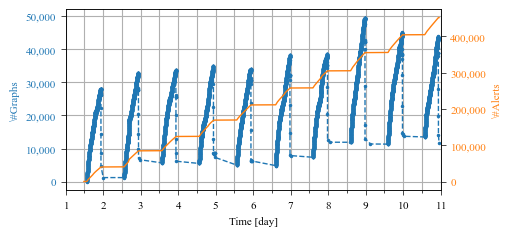

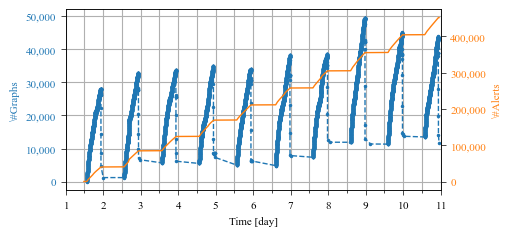

In [14]:
plot_dataset(df_ids2018_apt_ranking)

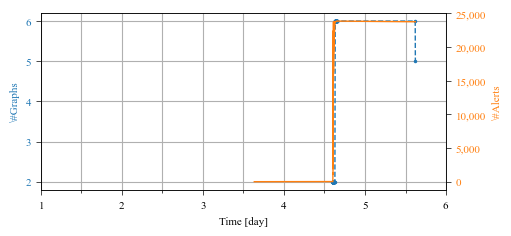

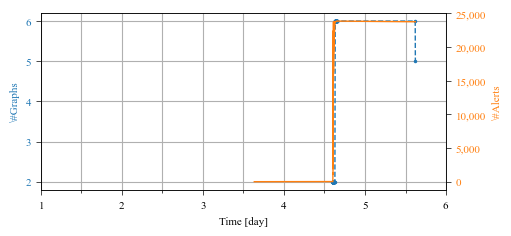

In [15]:
plot_dataset(df_ids2017_ranking)

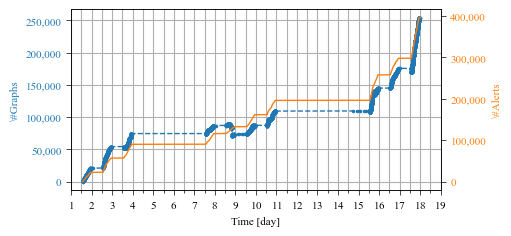

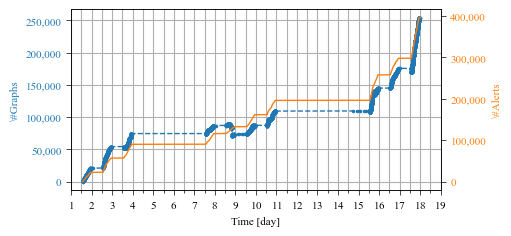

In [16]:
plot_dataset(df_ids2018_ranking)

In [17]:
def ap_at_k(df, k):
    def ap(row):
        average_precision = 0
        if row["rank"] <= k:
            # AP: {number of positive elements so far} / {position}: 1 / position
            average_precision = 1/row["rank"]
        
        # because there is just one item, we do not need to sum
        # AP@k = 1/{ground truth predicted}: 1/1 (dropped) because only one element
        row["ap"] = average_precision

        return row

    return df.apply(ap, axis=1)

In [51]:
import matplotlib.ticker as mtick
import math

def plot_ap(configs, no_legend=False):
    colors = ["xkcd:blue green", "xkcd:violet", "xkcd:goldenrod"]
    markers = ["o", "x", "s"]
    linestyles = [":", "-","--"]

    df_s = [ap_at_k(config["data"], config["k"]) for config in configs]


    legend_space = 0
    if no_legend:
        legend_space = LEGEND_HEIGHT

    fig, ax = plt.subplots(figsize=(LINEWIDTH, HEIGHT-legend_space), layout="constrained")

    ax.grid(linestyle='-', linewidth=0.25, which="major", axis="y", zorder=0)

    for i in range(len(configs)):
        zorder = i + 1
        df = df_s[i]
        k = configs[i]["k"]
        name = configs[i]["name"]
        configs[i]["data"] = df
        color = colors[i % len(colors)]
        v = ax.plot(df["time_normalized"], df["ap"],label=f"AP@{k:,} ({name})", marker=markers[i % len(markers)], markersize=3, linestyle=linestyles[i % len(linestyles)], drawstyle="steps-post", color=color, zorder=zorder)
        seconds_per_day = (24 * 60 * 60)
        ax.plot([df["time_normalized"].iloc[-1], math.ceil(df["time_normalized"].iloc[-1] / seconds_per_day) * seconds_per_day - 1], [df["ap"].iloc[-1], df["ap"].iloc[-1]], linestyle="-", color=color, zorder=zorder)
        ax.plot([df["time_normalized"].iloc[0], 0], [df["ap"].iloc[0], df["ap"].iloc[0]], linestyle="-", color=color, zorder=zorder)

    ax.set_xlabel("Time [days]")
    ax.set_ylabel("Average\nPrecision (AP)")

    ax.set_xlim(1, math.ceil(df.iloc[len(df.index)-1]["time_normalized"])-0.01)

    ax.xaxis.set_major_locator(mtick.MultipleLocator(1))
    ax.xaxis.set_minor_locator(mtick.MultipleLocator(0.25))
    ax.yaxis.set_major_locator(mtick.MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(mtick.MultipleLocator(0.125))
    ax.set_ylim(-0.05, 1.05)

    return fig, ax

In [77]:
def draw_stages(ax, lines):
    (x_min, x_max) = ax.get_xlim()

    def to_normalized_time(line):
        return (line["day"]+ line["hour"] * (1/24))

    text_offset_size = (x_max - x_min)

    attack_start = 0
    attack_end = 0
    color = "black"

    for i in range(len(lines)):
        line = lines[i]
        start = to_normalized_time(line)

        if i == 0:
            attack_start = start
        if i == len(lines) - 1:
            attack_end = start

        ax.axvline(x=start, color=color, linestyle="-")

        x_offset = 0
        if i > 0 and abs(start - to_normalized_time(lines[i-1])) < 1:
            x_offset = 8
        else:
            x_offset = -8

        x_offset = x_offset / 2 * 1.25

        fontsize = 6
        stage_size = fontsize
        y_offset = stage_size - 1
        padding = 2

        line["stages"].reverse()

        for i in range(len(line["stages"])):
            stage = line["stages"][i]

            xy=(start, 1)
            xytext=(x_offset, -y_offset)

            ax.annotate("x", color=color, xy=xy, xytext=xytext, textcoords="offset points", ha="center", va="center", fontsize=0, bbox=dict(boxstyle=f"circle,pad={stage_size/1.95}", fc=color, ec=color, lw=1))
            ax.annotate(stage, xy=xy, xytext=(xytext[0], xytext[1]-0.25), bbox=dict(pad=0, facecolor="none", edgecolor="none"), textcoords="offset points", fontweight="bold", color="white", fontsize=fontsize, ha="center", va="center", font="Arial")

            y_offset += stage_size + padding

            if i + 1 < len(line["stages"]):
                ax.annotate("+", xy=(start, 1), xytext=(xytext[0], -y_offset+0.25), textcoords="offset points", color=color, font="Arial", ha="center", va="center", fontsize=fontsize)
                y_offset += fontsize
    
    ax.plot([], color=color, label='Stage', linestyle="-")

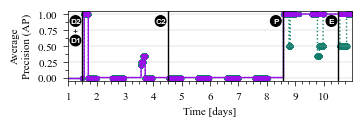

In [78]:
configs_ids2018_apt = [{
    "k": 10,
    "name": "equal weights",
    "data": df_ids2018_apt_ranking_equal_weights
},
{
    "k": 10,
    "name": "custom weights",
    "data": df_ids2018_apt_ranking
}]

fig_map_ids2018_apt, ax = plot_ap(configs_ids2018_apt, no_legend=True)

steps = [
    {
        "day": 1,
        "hour": 12,
        "stages": ["D1", "D2"],
    },
    {
        "day": 4,
        "hour": 12,
        "stages": ["C2"],
    },
    {
        "day": 8,
        "hour": 13.50,
        "stages": ["P"],
    },
    {
        "day": 10,
        "hour": 12.55,
        "stages": ["E"],
    }
]

draw_stages(ax, steps)

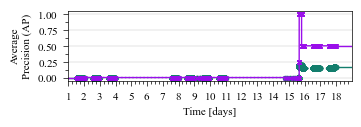

In [79]:
configs_ids2018 = [{
    "k": 10,
    "name": "equal weights",
    "data": df_ids2018_ranking_equal_weights,
},
{
    "k": 10,
    "name": "custom weights",
    "data": df_ids2018_ranking,
}]

fig_map_ids2018, ax = plot_ap(configs_ids2018, no_legend=True)

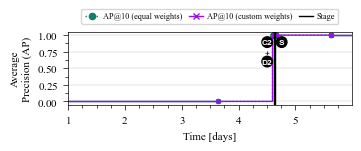

In [82]:
configs_ids2017 = [{
    "k": 10,
    "name": "equal weights",
    "data": df_ids2017_ranking_equal_weights,
},
{
    "k": 10,
    "name": "custom weights",
    "data": df_ids2017_ranking,
}]

fig_map_ids2017, ax = plot_ap(configs_ids2017)

stages = [{
    "day": 4,
    "hour": 15,
    "stages": ["D2","C2"]
},
{
    "day": 4,
    "hour": 15.25,
    "stages": ["S"]
}]

draw_stages(ax, stages)
draw_legend(ax, ncol=3)

In [83]:
fig_map_ids2017.savefig("figures/ranking-ap-ids2017.pdf", transparent=True)
fig_map_ids2018.savefig("figures/ranking-ap-ids2018.pdf", transparent=True)
fig_map_ids2018_apt.savefig("figures/ranking-ap-ids2018-apt.pdf", transparent=True)

[np.float64(1.0), np.float64(0.37342452286518185), np.float64(0.3768156417132876), np.float64(0.37817276567666297)]


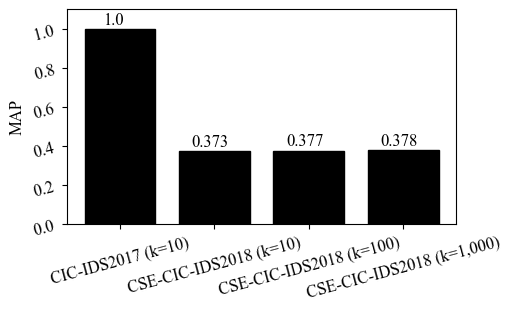

In [ ]:
# Mean average

def get_mean_ap(df, start, k=10):
    tick_rate = timedelta(days=1) / timedelta(seconds=1)
    start = start.total_seconds() / tick_rate

    df = ap_at_k(df, k)

    return df[df["time_normalized"] >= start]["ap"].mean()

keys = [
    "CIC-IDS2017 (k=10)",
    "CSE-CIC-IDS2018 (k=10)",
    "CSE-CIC-IDS2018 (k=100)",
    "CSE-CIC-IDS2018 (k=1,000)",
]

values = [
    get_mean_ap(df_ids2017_ranking, timedelta(days=4, hours=20, minutes=5, seconds=0)),
    get_mean_ap(df_ids2018_apt_ranking, timedelta(days=0, hours=0, minutes=0, seconds=0)),
    get_mean_ap(df_ids2018_apt_ranking, timedelta(days=0, hours=0, minutes=0, seconds=0), k=100),
    get_mean_ap(df_ids2018_apt_ranking, timedelta(days=0, hours=0, minutes=0, seconds=0), k=1000),
]

colors = [
    "tab:purple", 
    "tab:green"
]

fig, ax = plt.subplots(layout="constrained", figsize=(5, 3))

bars = ax.bar(keys, values, width=0.75, color="black", edgecolor="black")

ax.set_ylabel(f"MAP")
ax.set_ylim(0, 1.1)

print(values)

for bar in bars:
    yval = bar.get_height()
    value = f"{round(yval, 3)}"
    ax.text(bar.get_x() + 0.3 - len(str(value)) * 0.0335, yval + .025, value)

ax.tick_params(rotation=15)